# Optional Lab - 神经元和层
在本实验中，我们将探索神经元/单元和层的内部工作原理。特别是，本实验将与你在课程 1 中掌握的模型（回归/线性模型和逻辑模型）进行类比。本实验将介绍 Tensorflow，并演示这些模型在该框架中的实现方式。
<figure>
   <img src="../work/images/C2_W1_NeuronsAndLayers.png"  style="width:540px;height:200px;" >
</figure>


## 软件包
**Tensorflow 和 Keras** 是由谷歌开发的机器学习软件包。2019 年，谷歌将 Keras 集成到 Tensorflow 中并发布了 Tensorflow 2.0。Keras 是由 François Chollet 独立开发的框架，它为 Tensorflow 创建了一个简单的、以层为中心的接口。本课程将使用 Keras 接口。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.layers import Dense, Input
from keras import Sequential
from keras.losses import MeanSquaredError, BinaryCrossentropy
from keras.activations import sigmoid
from lab_utils_common import dlc
from lab_neurons_utils import plt_prob_1d, sigmoidnp, plt_linear, plt_logistic
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

## 无激活函数的神经元 - 回归/线性模型

### 数据集
我们将使用课程 1 中的一个示例，即房价的线性回归。

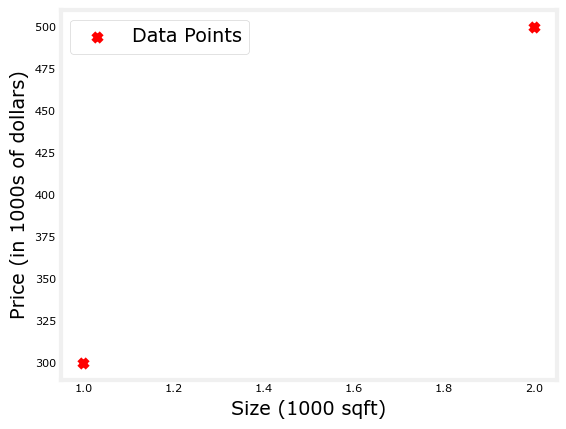

In [2]:
X_train = np.array([[1.0], [2.0]], dtype=np.float32)           #(size in 1000 square feet)
Y_train = np.array([[300.0], [500.0]], dtype=np.float32)       #(price in 1000s of dollars)
fig, ax = plt.subplots(1,1)
ax.scatter(X_train, Y_train, marker='x', c='r', label="Data Points")
ax.legend( fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')
plt.show()

### 回归/线性模型
没有激活函数的神经元实现的功能与课程 1 中的线性回归相同：
$$ f_{\mathbf{w},b}(x^{(i)}) = \mathbf{w}\cdot x^{(i)} + b \tag{1}$$



我们可以定义一个具有一个神经元或单元的层，并将其与熟悉的线性回归函数进行比较。

In [3]:
linear_layer = Dense(units=1, activation = 'linear', )

让我们检查一下权重。

In [4]:
linear_layer.get_weights()

[]

由于权重尚未实例化，所以目前没有权重。让我们在`X_train`中的一个示例上尝试该模型。这将触发**权重的实例化**。请注意，层的输入必须是二维的，所以我们将对其进行重塑reshape。

In [6]:
a1 = linear_layer(X_train[0].reshape(-1,1))
print(a1)

tf.Tensor([[1.22]], shape=(1, 1), dtype=float32)


结果是一个形状为(1,1)的张量（矩阵的另一个名称）。  
现在让我们看看权重$w$和偏差$b$。这些权重$w$被随机初始化为较小的数字，而偏差$b$默认初始化为零。

In [7]:
w, b= linear_layer.get_weights()
print(f"w = {w}, b={b}")

w = [[1.22]], b=[0.]


线性回归模型（1）具有单个输入特征时将有一个权重和一个偏差。这与我们上面的`linear_layer`的维度相匹配。

权重被初始化为随机值，所以让我们将它们设置为一些已知值。

In [8]:
set_w = np.array([[200]])
set_b = np.array([100])

# set_weights takes a list of numpy arrays
linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


让我们将方程（1）与输出层进行比较。

In [9]:
print(X_train)
print(X_train[1].reshape(1,1))
a1 = linear_layer(X_train[1].reshape(1,1))
print(a1)
alin = np.dot(set_w,X_train[1].reshape(1,1)) + set_b
print(alin)

[[1.]
 [2.]]
[[2.]]
tf.Tensor([[500.]], shape=(1, 1), dtype=float32)
[[500.]]


它们产生相同的值！

现在，我们可以使用我们的线性层对我们的训练数据进行预测。

In [10]:
prediction_tf = linear_layer(X_train)
print(prediction_tf)
prediction_np = np.dot( X_train, set_w) + set_b
print(prediction_np)

tf.Tensor(
[[300.]
 [500.]], shape=(2, 1), dtype=float32)
[[300.]
 [500.]]


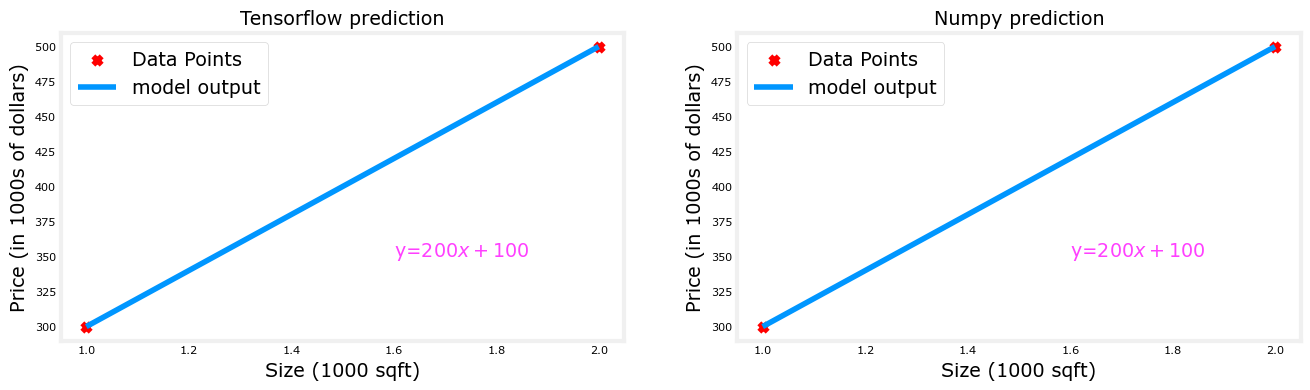

In [11]:
plt_linear(X_train, Y_train, prediction_tf, prediction_np)

## 具有 Sigmoid 激活函数的神经元
具有 Sigmoid 激活函数的神经元/单元所实现的函数与课程 1 中的逻辑回归相同：
$$ f_{\mathbf{w},b}(x^{(i)}) = g(\mathbf{w}x^{(i)} + b) \tag{2}$$
这里 $$g(x) = sigmoid(x)$$ 

让我们将$w$和$b$设置为一些已知值并检查模型。


### 数据集
我们将使用课程 1（逻辑回归）中的一个示例。

In [12]:
X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)  # 2-D Matrix
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)  # 2-D Matrix

In [13]:
X_train

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.]], dtype=float32)

In [14]:
Y_train

array([[0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.]], dtype=float32)

In [15]:
pos = Y_train == 1
neg = Y_train == 0
print(pos)
X_train[pos]

[[False]
 [False]
 [False]
 [ True]
 [ True]
 [ True]]


array([3., 4., 5.], dtype=float32)

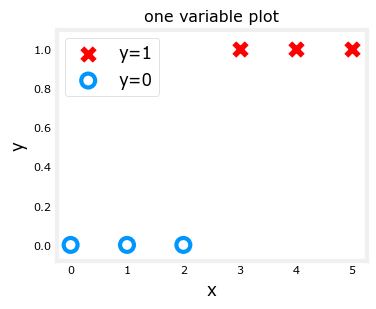

In [16]:
pos = Y_train == 1
neg = Y_train == 0

fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(X_train[pos], Y_train[pos], marker='x', s=80, c = 'red', label="y=1")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, label="y=0", facecolors='none', edgecolors=dlc["dlblue"],lw=3)

ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_title('one variable plot')
ax.legend(fontsize=12)
plt.show()

### 逻辑神经元
我们可以通过添加一个 sigmoid 激活函数来实现一个“逻辑神经元”。神经元的功能随后由上面的（2）描述。  

本节将创建一个包含我们的逻辑层的 Tensorflow 模型，以展示创建模型的另一种方法。Tensorflow 最常用于创建多层模型。[Sequential](https://keras.io/guides/sequential_model/)模型是构建这些模型的一种便捷方式。

In [ ]:
model = Sequential(
    [
       Input(shape=(1,)),  #输入的形状(None, 1)，提前要转置成（1, None）
       Dense(1, activation = 'sigmoid', name='L1')  #输出的形状(None,1)
    ]
)

In [21]:
print(f"输入的ndim: {len(model.input_shape)}, 输入的形状={model.input_shape}")
print(f"输出的ndim: {len(model.output_shape)}, 输出的形状={model.output_shape}")

输入的ndim: 2, 输入的形状=(None, 1)
输出的ndim: 2, 输出的形状=(None, 1)


`model.summary()`显示了模型中的层和参数数量。这个模型只有一层，并且那一层只有一个单元。该单元有两个参数，$w$和$b$。

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
logistic_layer = model.get_layer('L1')
w,b = logistic_layer.get_weights()
print(w,b)
print(w.shape,b.shape)

[[1.7]] [0.]
(1, 1) (1,)


让我们将权重和偏差设置为已知值。

In [25]:
set_w = np.array([[2]])
set_b = np.array([-4.5])
# set_weights takes a list of numpy arrays
logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


让我们将方程（2）与输出层进行比较。

In [26]:
a1 = model.predict(X_train[0].reshape(1,1))
print(a1)
alog = sigmoidnp(np.dot(set_w,X_train[0].reshape(1,1)) + set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[0.01]]
[[0.01]]


它们产生相同的值！

现在，我们可以使用我们的逻辑层和 NumPy 模型对我们的训练数据进行预测。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━

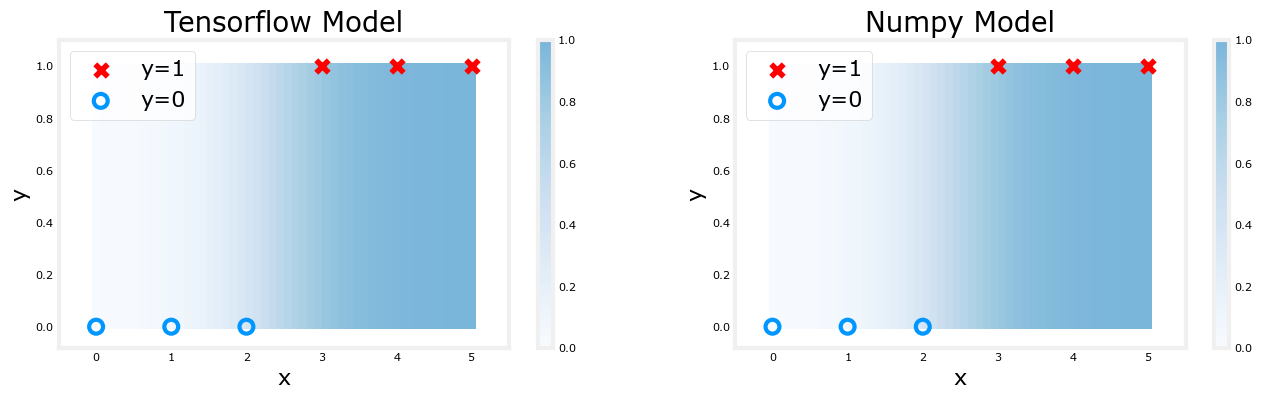

In [27]:
plt_logistic(X_train, Y_train, model, set_w, set_b, pos, neg)

上面的阴影反映了 sigmoid 的输出，其值在 0 到 1 之间变化。

### 恭喜！

你构建了一个非常简单的神经网络，并探索了神经元与课程 1 中的线性回归和逻辑回归的相似之处。
